# End-to-End Two-Stage HPO

**1 Trial = CLF → 집계 → FS → REG → RMSE**

- 단일 Optuna objective에서 전체 파이프라인 실행
- CLF/FS/REG 하이퍼파라미터를 동시에 최적화 (전역 최적)
- 웨이퍼맵 기반 피처 사전 필터링 적용

## 1. 환경 설정 및 데이터 로드

In [1]:
# ============================================================
# 환경 설정 + 데이터 로드
# ============================================================
import os, sys

try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.exists('/content/project/setup.py'):
        os.system('pip install -q gdown')
        os.system('gdown 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip')
        os.system('unzip -qo /content/code.zip -d /content/project')
        os.makedirs('/content/project/0_data', exist_ok=True)
        os.system('gdown 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip')
        os.system('unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data')
        os.remove('/content/project/0_data/dataset.zip')
    if not os.path.exists('/content/project/2_preprocessing/cleaning.py'):
        os.system('gdown 1Rh0ByOS4Gama8XHuvY7KkOHo278H9YLr -O /content/preprocessing.zip')
        os.system('unzip -qo /content/preprocessing.zip -d /content/project')
    if not os.path.exists('/content/project/3_modeling/modules/e2e_hpo.py'):
        os.system('gdown 1Vrn5LBl611rWbag7d09LZH68_lfpu6wP -O /content/modules.zip')
        os.makedirs('/content/project/3_modeling/modules', exist_ok=True)
        os.system('unzip -qo /content/modules.zip -d /content/project/3_modeling/modules')
    sys.path.insert(0, '/content/project')
    %run /content/project/setup.py
except ImportError:
    %run ../setup.py

# --- 기본 라이브러리 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- 프로젝트 유틸 ---
from utils.config import PROJECT_ROOT, SEED, TARGET_COL, KEY_COL, POSITION_COL
from utils.data import load_all, get_feat_cols, split_xs
from utils.evaluate import evaluate, postprocess
from utils.experiment import (
    log_experiment, check_exp_id, check_duplicate_params, download_from_drive,
)

# --- 전처리 모듈 ---
sys.path.insert(0, os.path.join(PROJECT_ROOT, '2_preprocessing'))
from cleaning import run_cleaning
from outlier import run_outlier_treatment

# --- 3_modeling 모듈 ---
sys.path.insert(0, os.path.join(PROJECT_ROOT, '3_modeling'))
from modules.e2e_hpo import run_e2e_optimization, rerun_best_trial

# --- 데이터 로드 ---
xs, ys = load_all()
feat_cols = get_feat_cols(xs)
xs_dict = split_xs(xs)
ys_train = ys['train']

print(f'Feature 수: {len(feat_cols)}')
print(f'Die 수: train={len(xs_dict["train"]):,}, val={len(xs_dict["validation"]):,}, test={len(xs_dict["test"]):,}')

setup 완료
Xs: (174980, 1091)  |  Ys: train=26,247, val=8,749, test=8,749
Feature 수: 1087
Die 수: train=104,988, val=34,996, test=34,996


## 2. 실험 설정

In [ ]:
# ============================================================
# 실험 설정 — 모든 파라미터를 여기서 제어
# ============================================================

EXP_ID = '3-2-101'
EXP_TYPE = 'E2E Two-Stage HPO'
EXP_MEMO = 'colab-t4'

# ── Test 평가 스위치 (test peeking 방지) ──
# True : Cell 12/17에서 test RMSE 계산·출력·로그 → 최종 제출 직전에만 권장
# False: test 예측 CSV는 저장하되 RMSE 계산·로그는 생략 (val 기준으로만 의사결정)
EVAL_TEST = False

# --- Google Drive 파일 ID (실험 로그) ---
XLSX_GDRIVE_ID = '1IgaNh7ixgqpmH5PiwmSFbK2li6GODdew'
JSON_GDRIVE_ID = '1ycr6n5Ty_jzl4F-qQE4Cv5nS2WbIAZih'

# --- 전처리 ---
cleaning_params = dict(
    const_threshold=1e-6,
    missing_threshold=0.25,
    remove_duplicates=True,
    corr_threshold=0.95,
    corr_keep_by='target_corr',   # |target corr| 큰 쪽 남김 (동률이면 std 큰 쪽)
    add_indicator=True,
    indicator_threshold=0.01,
    imputation_method='spatial',
    spatial_max_dist=2.0,
)

outlier_params = dict(
    method='winsorize',
    lower_pct=0.0,
    upper_pct=0.995,
)

# --- 샘플링 ---
sampling_params = dict(
    use_sampling=False,      # True: 빠른 탐색, False: 전체 데이터
    sample_frac=1.0,
)

# --- 웨이퍼맵 기반 피처 필터 ---
EXCLUDE_COLS = [
    # 예: 'X123', 'X456', ...
    # 웨이퍼맵 분석 결과를 여기에 추가
]

# ── 파이프라인 스위치 (pipeline_config) ──
# 이 dict의 모든 값이 JSON 실험 로그에 저장됩니다.
pipeline_config = dict(
    input_level='die',      # 'die' | 'unit' (unit이면 CLF 자동 OFF)
    run_clf=True,           # False → 분류 스킵, 회귀만
    clf_output='proba',     # 'proba' | 'binary' (P(Y>0) 확률 vs 0/1)
    clf_filter=False,       # True → 0 예측 샘플을 회귀에서 제외
    clf_optuna=True,        # False → CLF 기본 파라미터 (1회 캐싱)
    run_fs=False,            # False → Feature Selection 스킵
    fs_optuna=False,         # False → 고정 top_k (1회 캐싱)
    reg_level='position',       # 'unit' | 'position'
    reg_optuna=True,        # False → REG 기본 파라미터 (1회 캐싱)
)

# ── E2E HPO 설정 ──
e2e_params = dict(
    clf_model='lgbm',
    reg_model='lgbm',
    n_trials=15,
    n_folds=3,
    clf_early_stop=50,
    reg_early_stop=50,
    imbalance_method='scale_pos_weight',
    agg_funcs=['mean', 'std', 'cv', 'range', 'min', 'max', 'median'],
    top_k_range=(50, 500),  # fs_optuna=True 일 때 탐색 범위
    top_k_fixed=200,        # fs_optuna=False 일 때 고정 값
    clf_fixed={},           # CLF 고정 파라미터 (탐색 제외)
    reg_fixed={},           # REG 고정 파라미터 (예: {'objective': 'poisson'})
)

# ── Rerun 설정 (best trial 재실행) ──
# mode='single' : train 100% 단일 모델 (빠름, 데이터 최대 활용) — 기본값
# mode='kfold'  : n_folds CV 앙상블 (느림, 약간의 variance 감소)
#
# ⚠️ 이 rerun_params는 Cell 12 (단일 E2E rerun) 와
#    Cell 16 (앙상블 base rerun) 모두에 적용됨.
#    앙상블은 OOF가 필요하므로 ensemble_config['force_kfold_mode']=True 이면
#    mode='single'이어도 자동으로 'kfold'로 덮어써진다.
rerun_params = dict(
    mode='kfold',           # 'single' | 'kfold'
    n_folds=5,               # mode='kfold'일 때만 사용
    es_holdout=0.1,          # mode='single'일 때 ES용 holdout 비율
    clf_early_stop=100,
    reg_early_stop=100,
)

LABEL_COL = 'label_bin'

# ── 앙상블 후보 (clf_model, reg_model) ──
# 모델 간 상관을 낮추기 위해 GBDT + 비GBDT 섞는 것을 권장
ensemble_candidates = [
    ('lgbm', 'lgbm'),       # 기본 후보
    ('xgb', 'xgb'),         # 다른 GBDT
    ('lgbm', 'catboost'),   # CatBoost reg
    ('lgbm', 'rf'),         # 비GBDT (배깅 계열) — 상관 낮춤
]

# ── 앙상블 설정 (전부 스위치) ──
ensemble_config = dict(
    # ── 마스터 스위치 ──
    enabled=True,                     # False → 앙상블 전체 스킵
    method='blend',                    # 'blend' | 'stacking' | 'both' | 'none'
    # ── 블렌딩 ──
    blend_optimizer='slsqp',          # 'slsqp' | 'optuna' | 'equal'
    blend_include_equal=True,         # SLSQP 써도 equal 같이 출력 (검증용)
    blend_optuna_trials=200,
    # ── 스태킹 ──
    stacking_meta='ridge',            # 'ridge' | 'lgbm' | 'auto'
    stacking_include_clf_proba=True,  # meta feature에 clf proba 추가
    stacking_ridge_alpha=None,        # None → RidgeCV 자동
    stacking_nested_cv=True,          # True → meta learner를 k-fold로 학습 (진짜 meta-OOF)
    stacking_meta_folds=5,
    stacking_lgbm_n_estimators=300,   # LGBM meta 고정 (early stop 없음 → val 누수 차단)
    # ── base rerun (⚠️ rerun_params 가 전달되면 n_folds_rerun 은 무시됨) ──
    force_kfold_mode=True,            # 앙상블용은 kfold 강제 (OOF 필요). rerun_params['mode']='single'이어도 덮어씀
    n_folds_rerun=5,                  # (deprecated) rerun_params['n_folds']가 우선. 호환성 위해 유지
    # ── 오버피팅 방어 ──
    overfit_gap_warn=0.0005,
    conservative_selection=False,     # True → overfit gap 큰 방법을 best에서 제외
    # ── 후처리 ──
    clip_negative=True,
    verbose=True,
)

# --- 설정 출력 ---
print(f'실험번호: {EXP_ID} | {EXP_TYPE}')
print(f'CLF: {e2e_params["clf_model"]} | REG: {e2e_params["reg_model"]}')
print(f'Trials: {e2e_params["n_trials"]} | Folds: {e2e_params["n_folds"]}')
print(f'Top-K: range={e2e_params["top_k_range"]}, fixed={e2e_params["top_k_fixed"]}')
print(f'샘플링: {"ON" if sampling_params["use_sampling"] else "OFF"} (frac={sampling_params["sample_frac"]})')
print(f'Rerun: mode={rerun_params["mode"]}'
      + (f', n_folds={rerun_params["n_folds"]}' if rerun_params["mode"] == "kfold"
         else f', es_holdout={rerun_params["es_holdout"]}'))
print(f'제외 컬럼: {len(EXCLUDE_COLS)}개')
print(f'앙상블: {"ON" if ensemble_config["enabled"] else "OFF"}'
      + (f' (method={ensemble_config["method"]}, 후보 {len(ensemble_candidates)}개)'
         if ensemble_config["enabled"] else ''))
print(f'\n── Pipeline Config ──')
for k, v in pipeline_config.items():
    print(f'  {k}: {v}')

download_from_drive(XLSX_GDRIVE_ID, JSON_GDRIVE_ID)
check_exp_id(EXP_ID)

실험번호: 3-2-101 | E2E Two-Stage HPO
CLF: lgbm | REG: lgbm
Trials: 15 | Folds: 3
Top-K: range=(50, 500), fixed=200
샘플링: OFF (frac=1.0)
Rerun: mode=kfold, n_folds=5
제외 컬럼: 0개
앙상블: ON (method=blend, 후보 4개)

── Pipeline Config ──
  input_level: die
  run_clf: True
  clf_output: proba
  clf_filter: False
  clf_optuna: True
  run_fs: False
  fs_optuna: False
  reg_level: position
  reg_optuna: True


In [3]:
# # 더미 데이터를 XLSX_PATH / JSON_PATH 에 저장 (그 다음 셀에서 upload_to_drive 호출)
# import json
# import pandas as pd
# from utils.experiment import XLSX_PATH, JSON_PATH

# # ── 더미 엑셀 ──
# df_dummy = pd.DataFrame([
#     {
#         '실험번호': '9-9-003',
#         '날짜': '2026-04-08',
#         '타입': 'upload-test',
#         '베스트모델': 'dummy-lgbm',
#         'val_rmse': 0.012345,
#         'test_rmse': 0.013579,
#         'val_증감': None,
#         'test_증감': None,
#         '피처수': 200,
#         '메모': 'Drive 업로드 동작 확인용 더미 행',
#     },
#     {
#         '실험번호': '9-9-002',
#         '날짜': '2026-04-08',
#         '타입': 'upload-test',
#         '베스트모델': 'dummy-xgb',
#         'val_rmse': 0.012000,
#         'test_rmse': 0.013000,
#         'val_증감': -0.000345,
#         'test_증감': -0.000579,
#         '피처수': 250,
#         '메모': '두 번째 더미 행',
#     },
# ])
# df_dummy.to_excel(XLSX_PATH, index=False)
# print(f'[xlsx] {XLSX_PATH}')

# # ── 더미 JSON ──
# data_dummy = {
#     '9-9-001': {
#         'cleaning_params': {'const_threshold': 1e-6, 'missing_threshold': 0.25},
#         'model_params': {
#             'pipeline': 'upload-test',
#             'best_params': {'learning_rate': 0.05, 'num_leaves': 63},
#             'final_method': 'e2e_single',
#             'final_val_rmse': 0.012345,
#             'final_test_rmse': 0.013579,
#         },
#         'feature_cols': ['X0_mean', 'X1_std', 'X2_cv'],
#     },
#     '9-9-002': {
#         'cleaning_params': {'const_threshold': 1e-6, 'missing_threshold': 0.30},
#         'model_params': {
#             'pipeline': 'upload-test',
#             'best_params': {'learning_rate': 0.03, 'num_leaves': 127},
#             'final_method': 'ensemble_blend',
#             'final_val_rmse': 0.012000,
#             'final_test_rmse': 0.013000,
#         },
#         'feature_cols': ['X0_mean', 'X1_std', 'X2_cv', 'X3_range'],
#     },
# }
# with open(JSON_PATH, 'w', encoding='utf-8') as f:
#     json.dump(data_dummy, f, ensure_ascii=False, indent=2)
# print(f'[json] {JSON_PATH}')

## 3. 전처리 (클리닝 + 이상치)

In [4]:
# --- Step 1: 클리닝 ---
xs_train, xs_val, xs_test, clean_cols, clean_report = run_cleaning(
    xs, feat_cols, xs_dict,
    ys_train=ys_train,
    **cleaning_params,
)

print(f'\n클리닝 결과: {len(feat_cols)} -> {len(clean_cols)}개')

# --- Step 2: 이상치 처리 ---
xs_train, xs_val, xs_test, outlier_report = run_outlier_treatment(
    xs_train, xs_val, xs_test, clean_cols,
    **outlier_params,
)

# --- Step 3: 웨이퍼맵 기반 피처 필터 ---
if EXCLUDE_COLS:
    before = len(clean_cols)
    clean_cols = [c for c in clean_cols if c not in set(EXCLUDE_COLS)]
    print(f'\n웨이퍼맵 필터: {before} -> {len(clean_cols)}개 ({before - len(clean_cols)}개 제외)')

print(f'\n최종 피처 수: {len(clean_cols)}개')

클리닝 파이프라인 시작
원본 feature 수: 1087
[상수/극저분산 제거] threshold=1e-06
  제거: 105개, 잔여: 982개
    컬럼: 1087 → 982 (105개 제거)
    DataFrame: (104988, 986)

[고결측 제거] threshold=25%
  제거: 10개, 잔여: 972개
    컬럼: 982 → 972 (10개 제거)
    DataFrame: (104988, 976)

[중복 컬럼 제거] sample_n=5000
  제거: 26개, 잔여: 946개
    컬럼: 972 → 946 (26개 제거)
    DataFrame: (104988, 950)



NameError: name 'y_train' is not defined

## 4. Health Merge + 라벨 생성 + Position 분리

In [ ]:
# --- Health merge ---
die_train = xs_train.merge(ys['train'], on=KEY_COL, how='left')
die_val = xs_val.merge(ys['validation'], on=KEY_COL, how='left')
die_test = xs_test.merge(ys['test'], on=KEY_COL, how='left')

assert die_train[TARGET_COL].notna().all(), 'train health NaN!'
assert die_val[TARGET_COL].notna().all(), 'val health NaN!'
assert die_test[TARGET_COL].notna().all(), 'test health NaN!'
print(f'Die-level merge: train={die_train.shape}, val={die_val.shape}, test={die_test.shape}')

# --- 샘플링 (unit 기준, train만) ---
USE_SAMPLING = sampling_params['use_sampling']
SAMPLE_FRAC = sampling_params['sample_frac']

if USE_SAMPLING:
    all_units = die_train[KEY_COL].drop_duplicates()
    sampled_units = all_units.sample(frac=SAMPLE_FRAC, random_state=SEED)
    n_before = len(die_train)
    die_train = die_train[die_train[KEY_COL].isin(sampled_units)].reset_index(drop=True)
    print(f'\n샘플링 ON (frac={SAMPLE_FRAC})')
    print(f'  Unit: {len(all_units):,} -> {len(sampled_units):,}')
    print(f'  Die: {n_before:,} -> {len(die_train):,}')
else:
    print('\n샘플링 OFF -> 전체 데이터 사용')

# --- 라벨 생성: 0 vs >0 ---
for df in [die_train, die_val, die_test]:
    df[LABEL_COL] = (df[TARGET_COL] > 0).astype(int)

print(f'\n라벨 분포 (train):')
dist = die_train[LABEL_COL].value_counts().sort_index()
for k, v in dist.items():
    print(f'  {k}: {v:,} ({v / len(die_train) * 100:.1f}%)')

# --- Position별 분리 ---
positions = sorted(die_train[POSITION_COL].unique())
feat_cols_clean = clean_cols

pos_data = {}
for pos in positions:
    pos_data[pos] = {
        'train': die_train[die_train[POSITION_COL] == pos].reset_index(drop=True),
        'val':   die_val[die_val[POSITION_COL] == pos].reset_index(drop=True),
        'test':  die_test[die_test[POSITION_COL] == pos].reset_index(drop=True),
    }
    n = {k: len(v) for k, v in pos_data[pos].items()}
    print(f'Position {pos}: train={n["train"]:,}, val={n["val"]:,}, test={n["test"]:,}')

print(f'\nClean feature 수: {len(feat_cols_clean)}개')

Die-level merge: train=(104988, 746), val=(34996, 746), test=(34996, 746)

샘플링 OFF -> 전체 데이터 사용

라벨 분포 (train):
  0: 74,332 (70.8%)
  1: 30,656 (29.2%)
Position 1: train=26,247, val=8,749, test=8,749
Position 2: train=26,247, val=8,749, test=8,749
Position 3: train=26,247, val=8,749, test=8,749
Position 4: train=26,247, val=8,749, test=8,749

Clean feature 수: 741개


## 5. E2E Optuna HPO 실행

1 Trial = CLF → 집계 → FS(top-K) → REG → Val RMSE

In [ ]:
result = run_e2e_optimization(
    pos_data=pos_data,
    feat_cols=feat_cols_clean,
    pipeline_config=pipeline_config,
    label_col=LABEL_COL,
    **e2e_params,
)

study = result['study']
best_params = result['best_params']

print(f'\n── Best Trial ──')
print(f'Val RMSE: {result["best_value"]:.6f}')
print(f'\nBest params:')
for k, v in sorted(best_params.items()):
    print(f'  {k}: {v}')

  0%|          | 0/1 [00:00<?, ?it/s]


E2E HPO 완료 (1 trials)
Optuna ON: clf, reg
Best Val RMSE : 0.005810
Train RMSE    : 0.008296
N Features    : 742

── Best Trial ──
Val RMSE: 0.005810

Best params:
  clf_colsample_bytree: 0.15227525095137953
  clf_learning_rate: 0.24517932047070642
  clf_max_depth: 8
  clf_min_child_samples: 51
  clf_min_split_gain: 0.004619347374377372
  clf_n_estimators: 1186
  clf_num_leaves: 190
  clf_path_smooth: 1.0292247147901223
  clf_reg_alpha: 0.6245760287469893
  clf_reg_lambda: 0.002570603566117598
  clf_subsample: 0.5779972601681014
  reg_colsample_bytree: 0.5722807884690141
  reg_learning_rate: 0.15107024270948044
  reg_max_depth: 4
  reg_min_child_samples: 59
  reg_min_split_gain: 0.000784915956255507
  reg_n_estimators: 2913
  reg_num_leaves: 60
  reg_path_smooth: 6.974693032602092
  reg_reg_alpha: 7.71800699380605e-05
  reg_reg_lambda: 4.17890272377219e-06
  reg_subsample: 0.6521211214797689


## 6. Best Trial 재실행 (더 많은 Fold)

HPO에서 찾은 best params로 더 안정적인 예측을 생성합니다.

In [ ]:
final = rerun_best_trial(
    pos_data=pos_data,
    feat_cols=feat_cols_clean,
    best_params=best_params,
    pipeline_config=pipeline_config,
    clf_model=e2e_params['clf_model'],
    reg_model=e2e_params['reg_model'],
    label_col=LABEL_COL,
    imbalance_method=e2e_params['imbalance_method'],
    agg_funcs=e2e_params['agg_funcs'],
    top_k_fixed=e2e_params['top_k_fixed'],
    clf_fixed=e2e_params['clf_fixed'],
    reg_fixed=e2e_params['reg_fixed'],
    **rerun_params,
)

# --- Validation 평가 ---
y_val = final['unit_data']['val'][TARGET_COL].values
evaluate(y_val, final['val_pred'], label='E2E Rerun (val)')

# --- Test 평가 (EVAL_TEST=True 일 때만 실제 RMSE 계산) ---
from utils.evaluate import rmse
if EVAL_TEST:
    y_test = final['unit_data']['test'][TARGET_COL].values
    test_rmse_score = rmse(y_test, final['test_pred'])
    evaluate(y_test, final['test_pred'], label='E2E Rerun (test)')
else:
    test_rmse_score = None
    print('[test] EVAL_TEST=False → test RMSE 계산 생략 (test peeking 방지)')

Rerun CLF: lgbm, mode=kfold (folds=5)
Rerun REG: lgbm, features=742, mode=kfold (folds=5)
Rerun Val RMSE: 0.005810
[E2E Rerun (val)] RMSE = 0.005810  (n=8,749, zero=6,194(70.8%))
[test] EVAL_TEST=False → test RMSE 계산 생략 (test peeking 방지)


## 7. 결과 시각화

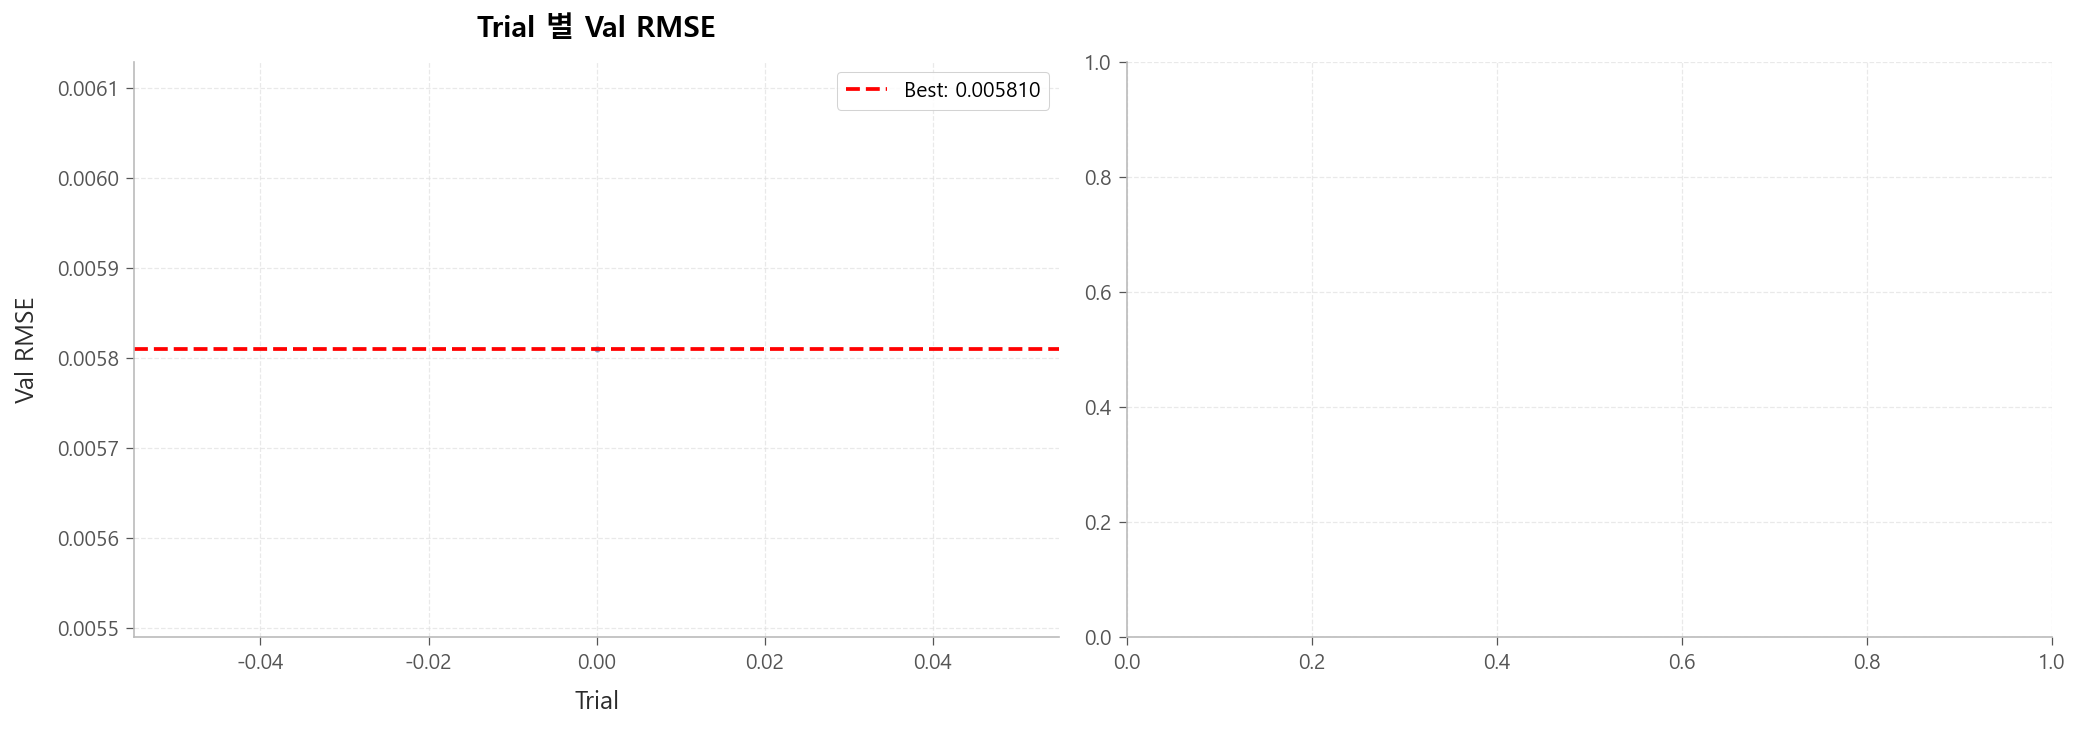

In [ ]:
# --- 결과 시각화 ---
has_study = study is not None

if has_study:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax_trial, ax_imp = axes[0], axes[1]

    # Trial RMSE 추이
    trials = study.trials
    vals = [t.value for t in trials if t.value is not None and t.value < float('inf')]
    ax_trial.plot(vals, 'o-', markersize=2, alpha=0.6)
    ax_trial.axhline(study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.6f}')
    ax_trial.set_xlabel('Trial')
    ax_trial.set_ylabel('Val RMSE')
    ax_trial.set_title('Trial 별 Val RMSE')
    ax_trial.legend()
else:
    fig, ax_imp = plt.subplots(1, 1, figsize=(7, 5))
    print('[Optuna OFF] Trial 추이 시각화 생략')

# Feature importance (top 20)
if final.get('importances') is not None:
    imp_series = pd.Series(final['importances']).sort_values(ascending=True).tail(20)
    imp_series.plot(kind='barh', ax=ax_imp)
    ax_imp.set_title(f'Top 20 Features (of {len(final["selected_cols"])})')
    ax_imp.set_xlabel('Importance (gain)')

plt.tight_layout()
plt.show()

## 8. 앙상블 (Blending / Stacking) — 선택

여러 (clf, reg) 후보 모델을 학습해 OOF/val/test 예측을 수집한 뒤, 블렌딩/스태킹으로 결합한다.

**핵심 설계**:
- `force_kfold_mode=True` → rerun이 자동으로 kfold로 전환되어 **train OOF** 확보 (val double-dip 방지)
- 가중치/meta-learner는 **train OOF에서만 학습**, val은 최종 검증용
- LGBM meta-learner는 early stopping 제거 + 강한 regularization (val 누수 차단)
- `stacking_nested_cv=True`로 meta learner도 k-fold 학습 → 진짜 meta-OOF
- `conservative_selection=True`면 overfit gap 큰 방법은 best 선정에서 제외
- `ENSEMBLE_CONFIG.enabled=False`로 두면 이 섹션 전체 스킵 가능

In [ ]:
from modules.ensemble import run_ensemble, DEFAULT_ENSEMBLE_CONFIG

# candidates / ensemble_config 는 셀 4(실험 설정)에서 정의됨
# 여기서는 실행만 담당 → 모든 설정이 로그에 자동 반영됨
#
# ★ 중복학습 방지 ★
# Cell 10 (HPO) + Cell 12 (rerun) 에서 이미 학습한 (clf_model, reg_model) 결과를
# precomputed 로 넘겨 앙상블 내부에서 재학습하지 않도록 한다.
# 재사용 조건: rerun_result 에 oof_pred 가 있어야 함 (= kfold 모드).

if ensemble_config['enabled']:
    # 단일 E2E 결과 재사용 dict
    _reuse_key = (e2e_params['clf_model'], e2e_params['reg_model'])
    precomputed_base = {
        _reuse_key: {
            'hpo_result': result,   # Cell 10 결과
            'rerun_result': final,  # Cell 12 결과 (mode='kfold' 이어야 재사용 가능)
        }
    }

    ens_result = run_ensemble(
        candidates=ensemble_candidates,
        pos_data=pos_data,
        feat_cols=feat_cols_clean,
        ensemble_config=ensemble_config,
        pipeline_config=pipeline_config,
        precomputed=precomputed_base,
        rerun_params=rerun_params,
        n_trials=e2e_params['n_trials'],
        n_folds=e2e_params['n_folds'],
        clf_early_stop=e2e_params['clf_early_stop'],
        reg_early_stop=e2e_params['reg_early_stop'],
        label_col=LABEL_COL,
        imbalance_method=e2e_params['imbalance_method'],
        agg_funcs=e2e_params['agg_funcs'],
        top_k_range=e2e_params['top_k_range'],
        top_k_fixed=e2e_params['top_k_fixed'],
    )

    print()
    print('── 최종 비교표 (val RMSE 오름차순) ──')
    display(ens_result['comparison'])
    print()
    print(f"★ Best method: {ens_result['best_method']}")
    print(f"   Val RMSE:  {ens_result['best_val_rmse']:.6f}")
else:
    ens_result = None
    print('[앙상블] enabled=False → 스킵')


██████████████████████████████████████████████████████████████████████
█  ENSEMBLE 파이프라인 시작
█  후보: 4개 — ['lgbm-lgbm', 'xgb-xgb', 'lgbm-catboost', 'lgbm-rf']
█  method=blend, blend_opt=slsqp, stacking_meta=ridge
█  force_kfold=True (rerun folds=5)
██████████████████████████████████████████████████████████████████████

[1/4] Base 모델: lgbm-lgbm
[lgbm-lgbm] precomputed 재사용 — HPO/rerun 스킵
[lgbm-lgbm] 수집 완료 — val RMSE: 0.005810

[2/4] Base 모델: xgb-xgb


  0%|          | 0/1 [00:00<?, ?it/s]


E2E HPO 완료 (1 trials)
Optuna ON: clf, reg
Best Val RMSE : 0.005964
Train RMSE    : 0.008412
N Features    : 742

[xgb-xgb] Rerun mode=kfold, folds=5
Rerun CLF: xgb, mode=kfold (folds=5)
Rerun REG: xgb, features=742, mode=kfold (folds=5)
Rerun Val RMSE: 0.005940
[xgb-xgb] 수집 완료 — val RMSE: 0.005940

[3/4] Base 모델: lgbm-catboost


  0%|          | 0/1 [00:00<?, ?it/s]


E2E HPO 완료 (1 trials)
Optuna ON: clf, reg
Best Val RMSE : 0.005809
Train RMSE    : 0.008296
N Features    : 742

[lgbm-catboost] Rerun mode=kfold, folds=5
Rerun CLF: lgbm, mode=kfold (folds=5)
Rerun REG: catboost, features=742, mode=kfold (folds=5)
Rerun Val RMSE: 0.005815
[lgbm-catboost] 수집 완료 — val RMSE: 0.005815

[4/4] Base 모델: lgbm-rf


  0%|          | 0/1 [00:00<?, ?it/s]


E2E HPO 완료 (1 trials)
Optuna ON: clf, reg
Best Val RMSE : 0.005826
Train RMSE    : 0.008306
N Features    : 742

[lgbm-rf] Rerun mode=kfold, folds=5
Rerun CLF: lgbm, mode=kfold (folds=5)
Rerun REG: rf, features=742, mode=kfold (folds=5)
Rerun Val RMSE: 0.005828
[lgbm-rf] 수집 완료 — val RMSE: 0.005828

──────────────────────────────────────────────────────────────────────
[블렌딩 실행] optimizer=slsqp
──────────────────────────────────────────────────────────────────────

██████████████████████████████████████████████████████████████████████
█  앙상블 결과 비교 (val RMSE 오름차순)
██████████████████████████████████████████████████████████████████████
            method  val_rmse  train_rmse  overfit_gap  abs_gap  warn
    base_lgbm-lgbm  0.005810    0.008295    -0.002484 0.002484  True
base_lgbm-catboost  0.005815    0.008307    -0.002493 0.002493  True
       blend_slsqp  0.005819    0.008288    -0.002469 0.002469  True
       blend_equal  0.005819    0.008297    -0.002477 0.002477  True
      base_lgbm

,method,val_rmse,train_rmse,overfit_gap,abs_gap,warn
0,base_lgbm-lgbm,0.005810,0.008295,-0.002484,0.002484,True
1,base_lgbm-catboost,0.005815,0.008307,-0.002493,0.002493,True
2,blend_slsqp,0.005819,0.008288,-0.002469,0.002469,True
3,blend_equal,0.005819,0.008297,-0.002477,0.002477,True
4,base_lgbm-rf,0.005828,0.008287,-0.002459,0.002459,True
5,base_xgb-xgb,0.005940,0.008392,-0.002452,0.002452,True



★ Best method: base_lgbm-lgbm
   Val RMSE:  0.005810


In [ ]:
# ── 최종 선정 + CSV 출력 ──
from utils.evaluate import rmse, evaluate
from utils.config import OUTPUT_DIR

# ─────────────────────────────────────────────────────────
# 1) Single E2E (셀 12의 rerun 결과) — 항상 존재
# ─────────────────────────────────────────────────────────
single_val_rmse  = float(final['val_rmse'])
single_test_rmse = float(test_rmse_score) if test_rmse_score is not None else None
single_val_pred  = final['val_pred']
single_test_pred = final['test_pred']
single_key_val   = final['unit_data']['val'][KEY_COL].values
single_key_test  = final['unit_data']['test'][KEY_COL].values

single_val_path  = os.path.join(OUTPUT_DIR, f'{EXP_ID}_e2e_val.csv')
single_test_path = os.path.join(OUTPUT_DIR, f'{EXP_ID}_e2e_test.csv')
pd.DataFrame({KEY_COL: single_key_val,  TARGET_COL: single_val_pred }).to_csv(single_val_path,  index=False)
pd.DataFrame({KEY_COL: single_key_test, TARGET_COL: single_test_pred}).to_csv(single_test_path, index=False)
_single_test_str = f'{single_test_rmse:.6f}' if single_test_rmse is not None else 'N/A (EVAL_TEST=False)'
print(f'[E2E single] val RMSE={single_val_rmse:.6f} | test RMSE={_single_test_str}')
print(f'  → {single_val_path}')
print(f'  → {single_test_path}')

# ─────────────────────────────────────────────────────────
# 2) Ensemble best (enabled일 때만)
# ─────────────────────────────────────────────────────────
# ⚠️ 전제: 모든 앙상블 후보가 동일한 pipeline_config 를 공유해야 함.
#    후보별로 clf_filter / 전처리를 다르게 하면 unit 수·순서가 달라져
#    아래 reindex 가 깨지고 ensemble 내부 정합성 체크가 먼저 raise 된다.
#    (collect_base_predictions 에서도 np.array_equal 로 검증)
ensemble_test_rmse = None
if ens_result is not None:
    ens_method    = ens_result['best_method']
    ens_val_rmse  = float(ens_result['best_val_rmse'])
    ens_val_pred  = ens_result['best_val_pred']
    ens_test_pred = ens_result['best_test_pred']
    ens_key_val   = ens_result['shared']['key_val']
    ens_key_test  = ens_result['shared']['key_test']

    if EVAL_TEST:
        # ens_key_test 순서에 맞춰 y_test 정렬 (ensemble shared 에는 y_test 없음)
        y_test_lookup = pd.Series(
            final['unit_data']['test'][TARGET_COL].values,
            index=single_key_test,
        )
        y_test_aligned = y_test_lookup.reindex(ens_key_test).values
        assert not pd.isna(y_test_aligned).any(), 'key_test 정합성 실패 — ensemble과 single E2E 간 unit 순서 불일치'
        ensemble_test_rmse = float(rmse(y_test_aligned, ens_test_pred))
        evaluate(y_test_aligned, ens_test_pred, label=f'Ensemble {ens_method} (test)')

    ens_val_path  = os.path.join(OUTPUT_DIR, f'{EXP_ID}_ensemble_val.csv')
    ens_test_path = os.path.join(OUTPUT_DIR, f'{EXP_ID}_ensemble_test.csv')
    pd.DataFrame({KEY_COL: ens_key_val,  TARGET_COL: ens_val_pred }).to_csv(ens_val_path,  index=False)
    pd.DataFrame({KEY_COL: ens_key_test, TARGET_COL: ens_test_pred}).to_csv(ens_test_path, index=False)
    _ens_test_str = f'{ensemble_test_rmse:.6f}' if ensemble_test_rmse is not None else 'N/A (EVAL_TEST=False)'
    print(f'[Ensemble {ens_method}] val RMSE={ens_val_rmse:.6f} | test RMSE={_ens_test_str}')
    print(f'  → {ens_val_path}')
    print(f'  → {ens_test_path}')
else:
    print('[Ensemble] 실행 안 됨 (enabled=False)')

# ─────────────────────────────────────────────────────────
# 3) 최종 선정 (val RMSE 기준) → {EXP_ID}_final_val/test.csv
# ─────────────────────────────────────────────────────────
if ens_result is not None and ens_result['best_val_rmse'] < single_val_rmse:
    final_method        = f'ensemble_{ens_result["best_method"]}'
    final_val_rmse      = float(ens_result['best_val_rmse'])
    final_test_rmse     = ensemble_test_rmse  # may be None (EVAL_TEST=False)
    final_key_val       = ens_result['shared']['key_val']
    final_key_test      = ens_result['shared']['key_test']
    final_val_pred_out  = ens_result['best_val_pred']
    final_test_pred_out = ens_result['best_test_pred']
else:
    final_method        = 'e2e_single'
    final_val_rmse      = single_val_rmse
    final_test_rmse     = single_test_rmse  # may be None (EVAL_TEST=False)
    final_key_val       = single_key_val
    final_key_test      = single_key_test
    final_val_pred_out  = single_val_pred
    final_test_pred_out = single_test_pred

final_val_path  = os.path.join(OUTPUT_DIR, f'{EXP_ID}_final_val.csv')
final_test_path = os.path.join(OUTPUT_DIR, f'{EXP_ID}_final_test.csv')
pd.DataFrame({KEY_COL: final_key_val,  TARGET_COL: final_val_pred_out }).to_csv(final_val_path,  index=False)
pd.DataFrame({KEY_COL: final_key_test, TARGET_COL: final_test_pred_out}).to_csv(final_test_path, index=False)

print()
print(f'★ FINAL: {final_method}')
print(f'  Val RMSE : {final_val_rmse:.6f}')
_final_test_str = f'{final_test_rmse:.6f}' if final_test_rmse is not None else 'N/A (EVAL_TEST=False)'
print(f'  Test RMSE: {_final_test_str}')
print(f'  → {final_val_path}')
print(f'  → {final_test_path}')

[E2E single] val RMSE=0.005810 | test RMSE=N/A (EVAL_TEST=False)
  → c:\Users\COM\Desktop\기업연계프로젝트\4_output\3-2-100_e2e_val.csv
  → c:\Users\COM\Desktop\기업연계프로젝트\4_output\3-2-100_e2e_test.csv
[Ensemble base_lgbm-lgbm] val RMSE=0.005810 | test RMSE=N/A (EVAL_TEST=False)
  → c:\Users\COM\Desktop\기업연계프로젝트\4_output\3-2-100_ensemble_val.csv
  → c:\Users\COM\Desktop\기업연계프로젝트\4_output\3-2-100_ensemble_test.csv

★ FINAL: e2e_single
  Val RMSE : 0.005810
  Test RMSE: N/A (EVAL_TEST=False)
  → c:\Users\COM\Desktop\기업연계프로젝트\4_output\3-2-100_final_val.csv
  → c:\Users\COM\Desktop\기업연계프로젝트\4_output\3-2-100_final_test.csv


## 9. 실험 로그

In [ ]:
# ============================================================
# 실험 로그 — 모든 파라미터 기록 (JSON + XLSX 증분 저장)
# ============================================================
# 재현성 원칙: 이 JSON 한 개만 보고도 실험을 100% 재현할 수 있어야 함
# → 셀 4에서 정의한 모든 설정 dict를 통째로 저장

# 앙상블 결과 요약 + base 후보별 details (실행된 경우에만)
if ens_result is not None:
    ensemble_result_log = {
        'best_method': ens_result['best_method'],
        'best_val_rmse': float(ens_result['best_val_rmse']),
        'best_test_rmse': ensemble_test_rmse,
    }
    # ── base 후보별 재현 정보 (앙상블이 winner인 경우 필수) ──
    ensemble_base_details = {
        name: {
            'clf_model': r['clf_model'],
            'reg_model': r['reg_model'],
            'val_rmse': float(r['val_rmse']),
            'best_params': r['best_params'],
            'n_selected_cols': len(r.get('selected_cols', []) or []),
            'selected_cols': list(r.get('selected_cols', []) or []),
        }
        for name, r in ens_result['base_results'].items()
    }
else:
    ensemble_result_log = None
    ensemble_base_details = None

log_experiment(
    exp_id=EXP_ID,
    exp_type=EXP_TYPE,
    best_model=f'{final_method} ({e2e_params["reg_model"]})',
    val_rmse=final_val_rmse,
    test_rmse=final_test_rmse,
    n_features=len(final['selected_cols']),
    memo=EXP_MEMO,
    cleaning_params=cleaning_params,
    outlier_params=outlier_params,
    feature_sel_params={
        'method': 'e2e_top_k',
        'top_k': best_params.get('top_k'),
        'top_k_fixed': e2e_params['top_k_fixed'],
        'top_k_range': e2e_params['top_k_range'],
    },
    agg_params={
        'agg_funcs': e2e_params['agg_funcs'],
    },
    model_params={
        'pipeline': 'E2E Joint HPO',
        # ── 전체 설정 dict (재현용) ──
        'pipeline_config': pipeline_config,
        'e2e_params': e2e_params,
        'rerun_params': rerun_params,
        'sampling_params': sampling_params,
        'label_col': LABEL_COL,
        'exclude_cols': EXCLUDE_COLS,
        # ── 앙상블 설정 ──
        'ensemble_candidates': ensemble_candidates,
        'ensemble_config': ensemble_config,
        # ── 결과 (재현 검증용) ──
        'best_params': best_params,
        'best_val_rmse_hpo': result['best_value'],
        'best_val_rmse_rerun': final['val_rmse'],
        'best_test_rmse_rerun': test_rmse_score,
        'ensemble_result': ensemble_result_log,
        'ensemble_base_details': ensemble_base_details,
        # ── 최종 선정 ──
        'final_method': final_method,
        'final_val_rmse': final_val_rmse,
        'final_test_rmse': final_test_rmse,
    },
    feature_cols=final['selected_cols'],
    xlsx_gdrive_id=XLSX_GDRIVE_ID,
    json_gdrive_id=JSON_GDRIVE_ID,
)


  주의: 기준 실험 '3-2-001'이 없어 증감을 계산할 수 없습니다.

실험 기록 완료: 3-2-100
  타입: E2E Two-Stage HPO | 베스트: e2e_single (lgbm)
  Val RMSE:  0.005810
  Test RMSE: N/A
  피처수: 742 | 메모: colab-t4
  xlsx: c:\Users\COM\Desktop\기업연계프로젝트\4_output\experiments\experiments.xlsx
  json: c:\Users\COM\Desktop\기업연계프로젝트\4_output\experiments\experiments.json
